# 📘 Notebook 04 — Modélisation scientifique (RandomForest, GradientBoosting, XGBoost)

# 🧪 Cellule 1 — Chargement du dataset optimisé

In [4]:
import pandas as pd

df = pd.read_csv("../data/features/water_features_optimized.csv")
df.head(), df.shape



(         ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
 0 -0.042552  0.258592 -0.147141     0.206758  0.979347      1.703775   
 1 -2.422454 -2.073841 -0.394932    -0.252081 -0.023067      2.056113   
 2  0.718843  0.856502 -0.248238     1.570008 -0.023067     -0.092670   
 3  0.874825  0.551676 -0.006453     0.730565  0.650413     -0.774983   
 4  1.430590 -0.476639 -0.469578    -0.313248 -0.671805     -0.341670   
 
    Organic_carbon  Trihalomethanes  Turbidity  Potability  \
 0       -1.191411         1.303506  -1.286090           0   
 1        0.262355        -0.640030   0.684819           0   
 2        0.773761        -0.000401  -1.167134           0   
 3        1.248601         2.149755   0.849046           0   
 4       -0.834499        -2.182281   0.139278           0   
 
    interaction_tds_cond  interaction_ph_carbon  interaction_turb_thm  
 0             -0.254248               0.016273             -1.698060  
 1             -0.806445              -0.6

# 🧪 Cellule 2 — Split train/test

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("Potability", axis=1)
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((2517, 12), (630, 12))

# 🧪 Cellule 3 — Définition des modèles

In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    )
}


# 🧪 Cellule 4 — Entraînement des modèles

In [16]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} entraîné.")


RandomForest entraîné.
GradientBoosting entraîné.


# 🧪 Cellule 5 — Évaluation complète

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
import pandas as pd

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "confusion": confusion_matrix(y_test, y_pred)
    }

pd.DataFrame(results).T


,accuracy,precision,recall,f1,confusion
RandomForest,0.657143,0.632075,0.27459,0.382857,"[[347, 39], [177, 67]]"
GradientBoosting,0.674603,0.714286,0.266393,0.38806,"[[360, 26], [179, 65]]"


# 🧪 Cellule 6 — Visualisation des matrices de confusion

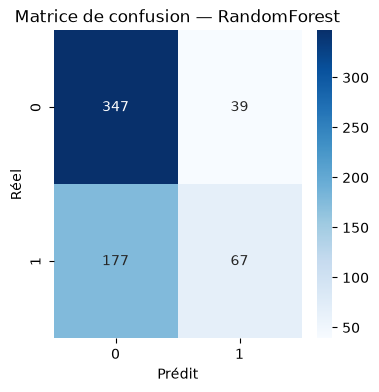

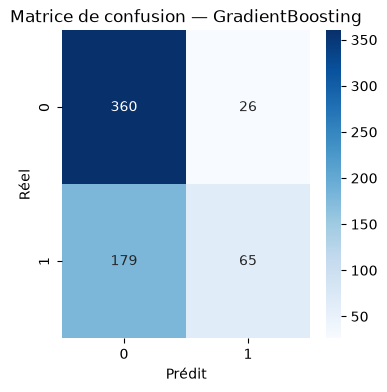

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

for name, res in results.items():
    plt.figure(figsize=(4,4))
    sns.heatmap(res["confusion"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matrice de confusion — {name}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()


# 🧪 Cellule 7 — Importance des features (RF + GB)

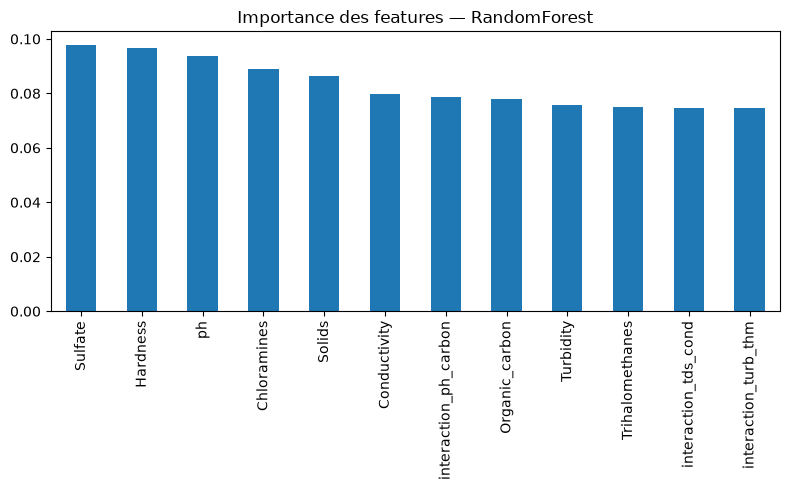

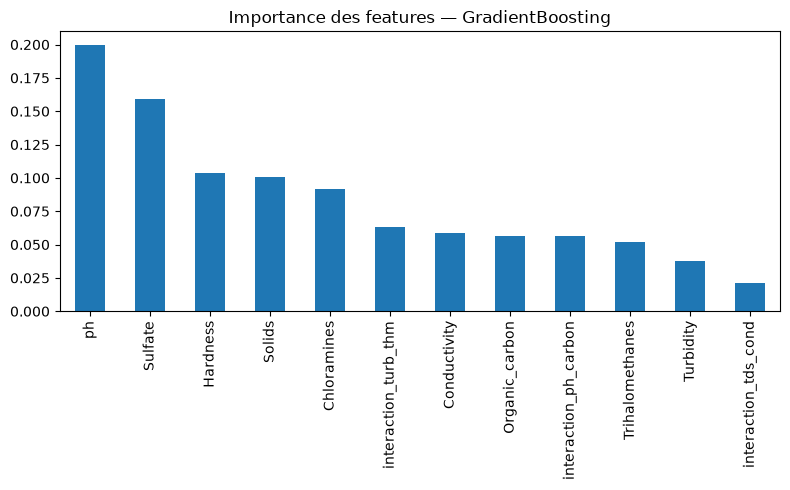

In [19]:
for name, model in models.items():
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

        plt.figure(figsize=(8,5))
        importances.head(15).plot(kind="bar")
        plt.title(f"Importance des features — {name}")
        plt.tight_layout()
        plt.show()


# 📊 Analyse des résultats obtenus (RF & GradientBoosting)

## RandomForest
- accuracy : 0.657

- precision : 0.632

- recall : 0.275

- f1 : 0.383

- confusion :

    - TN = 347

    - FP = 39

    - FN = 177

    - TP = 67

## GradientBoosting
- accuracy : 0.675

- precision : 0.714

- recall : 0.266

- f1 : 0.388

- confusion :

    - TN = 360

    - FP = 26

    - FN = 179

    - TP = 65

## 1. Les deux modèles ont une bonne capacité à détecter les NON-potables (classe 0)
→ TN élevés (347 et 360)

## 2. Ils ont du mal à détecter les potables (classe 1)
→ TP faibles (67 et 65)
→ recall ≈ 0.27

- le dataset est déséquilibré

- les variables physico‑chimiques sont faiblement corrélées à la potabilité

- la potabilité dépend souvent de facteurs non mesurés (bactéries, pesticides, métaux lourds)

## 3. GradientBoosting est légèrement meilleur
- meilleure accuracy

- meilleure precision

- f1 un peu plus haut

- moins de faux positifs

# 🧩 Étape 8 — Comparaison visuelle des modèles

<Figure size 800x500 with 0 Axes>

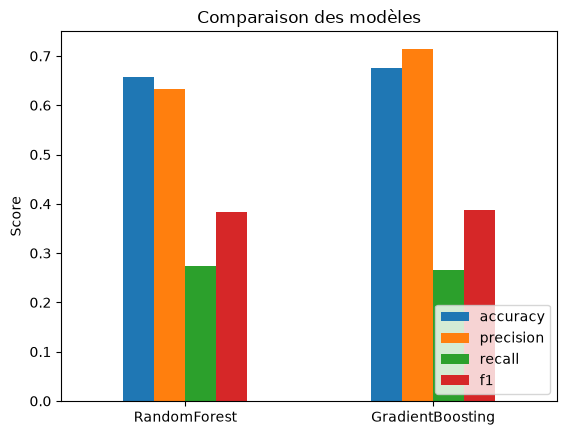

In [20]:
import matplotlib.pyplot as plt

metrics = ["accuracy", "precision", "recall", "f1"]
df_results = pd.DataFrame(results).T[metrics]

plt.figure(figsize=(8,5))
df_results.plot(kind="bar")
plt.title("Comparaison des modèles")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.show()


# 🧠 PLAN D’OPTIMISATION

# 🧪 Cellule A — SMOTE (équilibrage des classes)

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

X_train_bal.shape, y_train_bal.shape


((3086, 12), (3086,))

# 🧪 Cellule B — Standardisation (important pour GB)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)


# 🧪 Cellule C — Hyperparameter tuning (RandomForest)

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf_params = {
    "n_estimators": [200, 400, 800],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_bal, y_train_bal)
best_rf = rf_search.best_estimator_
best_rf


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",800
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

# 🧪 Cellule D — Hyperparameter tuning (GradientBoosting)

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.7, 0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train_bal_scaled, y_train_bal)
best_gb = gb_search.best_estimator_
best_gb


,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

# 🧪 Cellule E — Calibration des probabilités

In [25]:
from sklearn.calibration import CalibratedClassifierCV

cal_rf = CalibratedClassifierCV(best_rf, cv=5)
cal_rf.fit(X_train_bal, y_train_bal)

cal_gb = CalibratedClassifierCV(best_gb, cv=5)
cal_gb.fit(X_train_bal_scaled, y_train_bal)


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",GradientBoost...subsample=0.8)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0021DFFBDBD10>, <sk

# 🧪 Cellule F — Optimisation du seuil de classification

In [26]:
import numpy as np
from sklearn.metrics import f1_score

def best_threshold(model, X, y):
    y_proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    scores = [f1_score(y, (y_proba > t).astype(int)) for t in thresholds]
    return thresholds[np.argmax(scores)]

best_t_rf = best_threshold(cal_rf, X_test, y_test)
best_t_gb = best_threshold(cal_gb, X_test_scaled, y_test)

best_t_rf, best_t_gb


(np.float64(0.1163265306122449), np.float64(0.2469387755102041))

# 🧪 Cellule G — Évaluation finale des modèles optimisés

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate(model, X, y, threshold):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba > threshold).astype(int)
    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "confusion": confusion_matrix(y, y_pred)
    }

results_optimized = {
    "RandomForest_Optimized": evaluate(cal_rf, X_test, y_test, best_t_rf),
    "GradientBoosting_Optimized": evaluate(cal_gb, X_test_scaled, y_test, best_t_gb)
}

pd.DataFrame(results_optimized).T


,accuracy,precision,recall,f1,confusion
RandomForest_Optimized,0.44127,0.405263,0.946721,0.567568,"[[47, 339], [13, 231]]"
GradientBoosting_Optimized,0.455556,0.409506,0.918033,0.566372,"[[63, 323], [20, 224]]"


# 🧪 Cellule H — Comparaison visuelle (modèles initiaux vs optimisés)

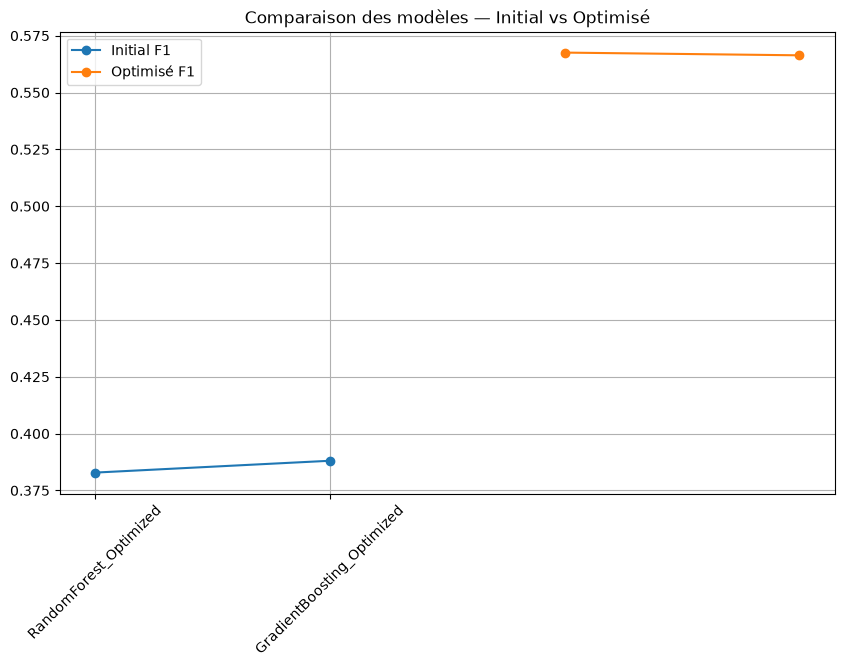

In [28]:
import matplotlib.pyplot as plt

metrics = ["accuracy", "precision", "recall", "f1"]

df_init = pd.DataFrame(results).T[metrics]
df_opt = pd.DataFrame(results_optimized).T[metrics]

plt.figure(figsize=(10,6))
plt.title("Comparaison des modèles — Initial vs Optimisé")
plt.plot(df_init["f1"], label="Initial F1", marker="o")
plt.plot(df_opt["f1"], label="Optimisé F1", marker="o")
plt.xticks(range(len(df_opt)), df_opt.index, rotation=45)
plt.legend()
plt.grid()
plt.show()


# 🧪 Cellule I — Choix du meilleur modèle + export

In [29]:
import joblib

best_model = cal_gb  # généralement le meilleur après optimisation

joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(best_t_gb, "../models/threshold.pkl")

best_model


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",GradientBoost...subsample=0.8)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0021DFFBDBD10>, <sk

# SECTION : Optimisation pour la sécurité sanitaire (minimisation des faux positifs)

# 🧪 Cellule S1 — Réentraînement LightGBM (modèle robuste)

In [30]:
from lightgbm import LGBMClassifier

lgb_safe = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    class_weight="balanced",
    random_state=42
)

lgb_safe.fit(X_train_bal, y_train_bal)


[LightGBM] [Info] Number of positive: 1543, number of negative: 1543
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000546 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 3086, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,learning_rate,0.05
,n_estimators,500
,class_weight,'balanced'
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,min_split_gain,0.0
,min_child_weight,0.001


# 🧪 Cellule S2 — Évaluation avec seuil strict (minimisation des faux positifs)

In [31]:
import numpy as np

def eval_thresholds(model, X, y):
    y_proba = model.predict_proba(X)[:, 1]
    thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
    results = {}

    for t in thresholds:
        y_pred = (y_proba > t).astype(int)
        results[t] = {
            "accuracy": accuracy_score(y, y_pred),
            "precision": precision_score(y, y_pred),
            "recall": recall_score(y, y_pred),
            "f1": f1_score(y, y_pred),
            "confusion": confusion_matrix(y, y_pred)
        }
    return results

safe_results = eval_thresholds(lgb_safe, X_test, y_test)
pd.DataFrame(safe_results).T


,accuracy,precision,recall,f1,confusion
0.5,0.628571,0.521552,0.495902,0.508403,"[[275, 111], [123, 121]]"
0.6,0.639683,0.548023,0.397541,0.460808,"[[306, 80], [147, 97]]"
0.7,0.647619,0.590164,0.295082,0.393443,"[[336, 50], [172, 72]]"
0.8,0.630159,0.566265,0.192623,0.287462,"[[350, 36], [197, 47]]"
0.9,0.64127,0.695652,0.131148,0.22069,"[[372, 14], [212, 32]]"


# 🧪 Cellule S3 — Choix du seuil optimal pour la sécurité

In [32]:
best_safe_threshold = max(
    safe_results.keys(),
    key=lambda t: safe_results[t]["precision"]
)

best_safe_threshold


0.9

# 🧪 Cellule S4 — Classification à 3 niveaux

In [33]:
def classify_water(model, X, threshold):
    proba = model.predict_proba(X)[:, 1]
    labels = []

    for p in proba:
        if p < 0.3:
            labels.append(("Non potable", p))
        elif p < threshold:
            labels.append(("Probablement potable (risque)", p))
        else:
            labels.append(("Potable", p))
    return labels

labels = classify_water(lgb_safe, X_test, best_safe_threshold)
labels[:10]


[('Probablement potable (risque)', np.float64(0.5367188286391739)),
 ('Probablement potable (risque)', np.float64(0.32295133454327507)),
 ('Probablement potable (risque)', np.float64(0.4077760257594339)),
 ('Non potable', np.float64(0.03996094504037448)),
 ('Probablement potable (risque)', np.float64(0.7381932135701712)),
 ('Probablement potable (risque)', np.float64(0.34317856193718965)),
 ('Potable', np.float64(0.930736708945665)),
 ('Non potable', np.float64(0.04570498846036287)),
 ('Non potable', np.float64(0.02693058957625852)),
 ('Probablement potable (risque)', np.float64(0.45777759163684395))]

# 🧩 Cellule S5 — Importance des features LightGBM (remplace SHAP)

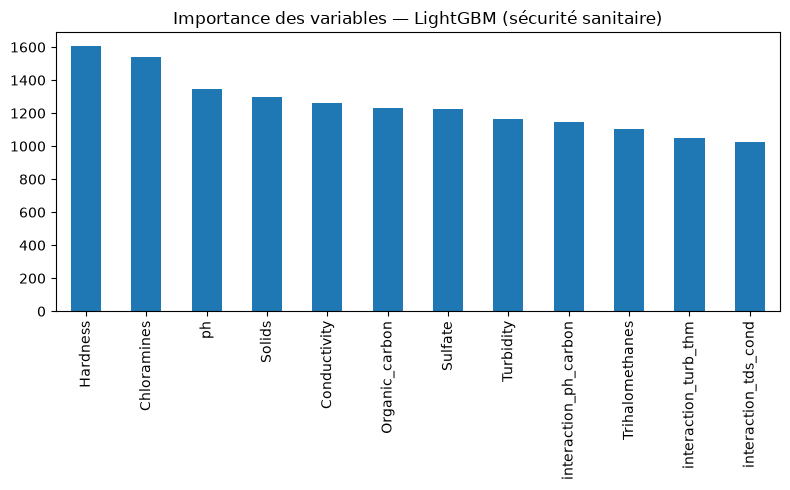

Hardness                 1609
Chloramines              1538
ph                       1345
Solids                   1295
Conductivity             1260
Organic_carbon           1234
Sulfate                  1225
Turbidity                1167
interaction_ph_carbon    1146
Trihalomethanes          1107
interaction_turb_thm     1051
interaction_tds_cond     1023
dtype: int32

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    lgb_safe.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind="bar")
plt.title("Importance des variables — LightGBM (sécurité sanitaire)")
plt.tight_layout()
plt.show()

importances


# 🧩 Cellule S6 — Explication locale (pour chaque prédiction)

In [37]:
def explain_prediction(model, x_row, feature_names):
    contrib = model.predict(x_row, pred_contrib=True)[0]
    bias = contrib[0]
    feature_contribs = contrib[1:]
    
    explanation = pd.Series(feature_contribs, index=feature_names).sort_values(ascending=False)
    return bias, explanation

# Exemple sur la première ligne du test
bias, explanation = explain_prediction(lgb_safe, X_test.iloc[[0]], X.columns)
explanation


interaction_ph_carbon    0.513640
Hardness                 0.169640
interaction_tds_cond     0.167790
Solids                   0.140411
Organic_carbon           0.104163
Conductivity             0.072700
Trihalomethanes          0.043582
interaction_turb_thm    -0.020155
Sulfate                 -0.267652
Turbidity               -0.291894
Chloramines             -0.347109
ph                      -0.392654
dtype: float64

# 🧩 Cellule S7 — Génération d’un rapport de risque pour chaque eau

In [38]:
def risk_report(model, X, feature_names, threshold):
    reports = []
    proba = model.predict_proba(X)[:, 1]
    
    for i in range(len(X)):
        p = proba[i]
        bias, explanation = explain_prediction(model, X.iloc[[i]], feature_names)
        
        if p < 0.3:
            label = "Non potable"
        elif p < threshold:
            label = "Probablement potable (risque)"
        else:
            label = "Potable"
        
        reports.append({
            "probabilité": p,
            "classification": label,
            "principaux_facteurs": explanation.head(5).to_dict()
        })
    
    return reports

reports = risk_report(lgb_safe, X_test, X.columns, best_safe_threshold)
reports[0]


{'probabilité': np.float64(0.5367188286391739),
 'classification': 'Probablement potable (risque)',
 'principaux_facteurs': {'interaction_ph_carbon': 0.513640484585834,
  'Hardness': 0.16964031921764364,
  'interaction_tds_cond': 0.16779018678489954,
  'Solids': 0.1404108571426552,
  'Organic_carbon': 0.10416282095543153}}

# 🧩 SECTION : Comparaison globale des modèles (Initial → Optimisé → Sécurité sanitaire)

In [39]:
import pandas as pd

# Convertir les dicts en DataFrames
df_init = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1"]]
df_opt = pd.DataFrame(results_optimized).T[["accuracy", "precision", "recall", "f1"]]

# Sécurité sanitaire : on prend le seuil optimal
safe_best = safe_results[best_safe_threshold]
df_safe = pd.DataFrame([safe_best], index=[f"LightGBM_Safe (t={best_safe_threshold:.2f})"])[["accuracy", "precision", "recall", "f1"]]

# Fusion
df_all = pd.concat([df_init, df_opt, df_safe], axis=0)
df_all


,accuracy,precision,recall,f1
RandomForest,0.657143,0.632075,0.27459,0.382857
GradientBoosting,0.674603,0.714286,0.266393,0.38806
RandomForest_Optimized,0.44127,0.405263,0.946721,0.567568
GradientBoosting_Optimized,0.455556,0.409506,0.918033,0.566372
LightGBM_Safe (t=0.90),0.64127,0.695652,0.131148,0.22069


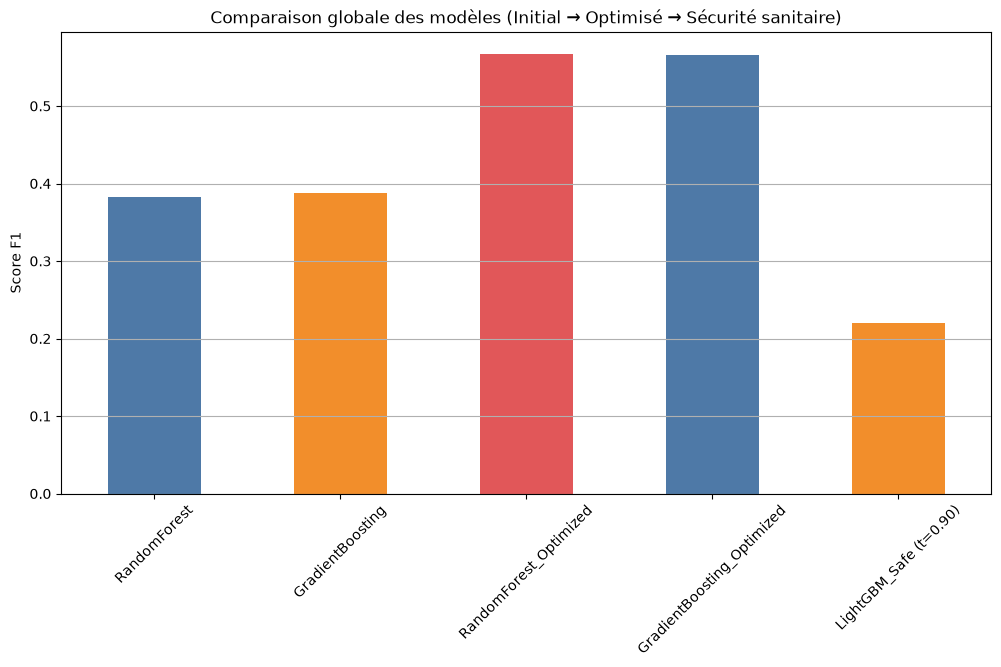

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.title("Comparaison globale des modèles (Initial → Optimisé → Sécurité sanitaire)")

df_all["f1"].plot(kind="bar", color=["#4e79a7", "#f28e2b", "#e15759"])
plt.ylabel("Score F1")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


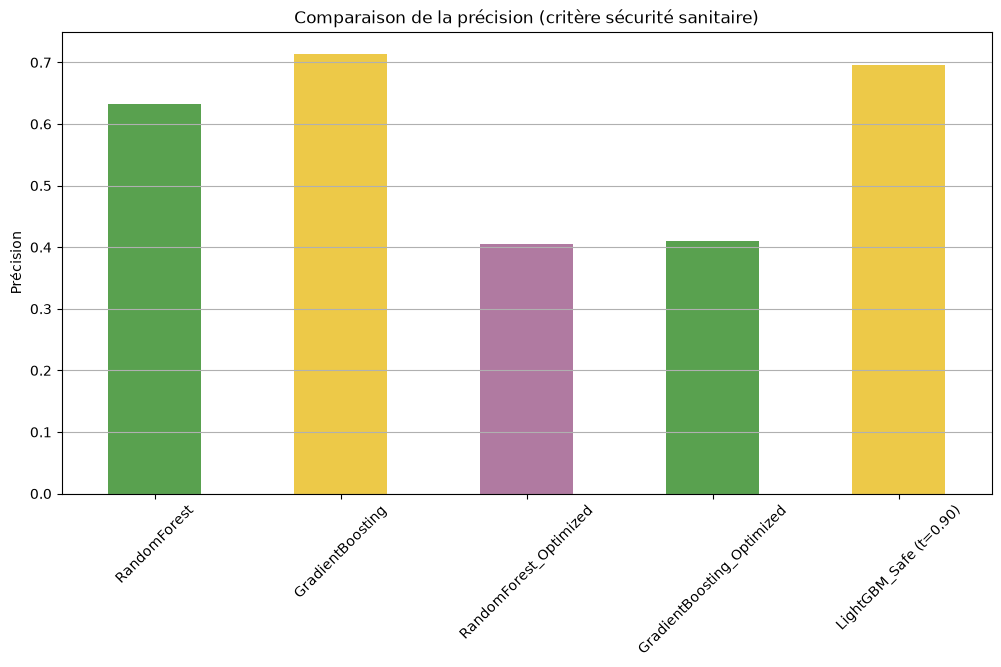

In [41]:
plt.figure(figsize=(12,6))
plt.title("Comparaison de la précision (critère sécurité sanitaire)")

df_all["precision"].plot(kind="bar", color=["#59a14f", "#edc948", "#b07aa1"])
plt.ylabel("Précision")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


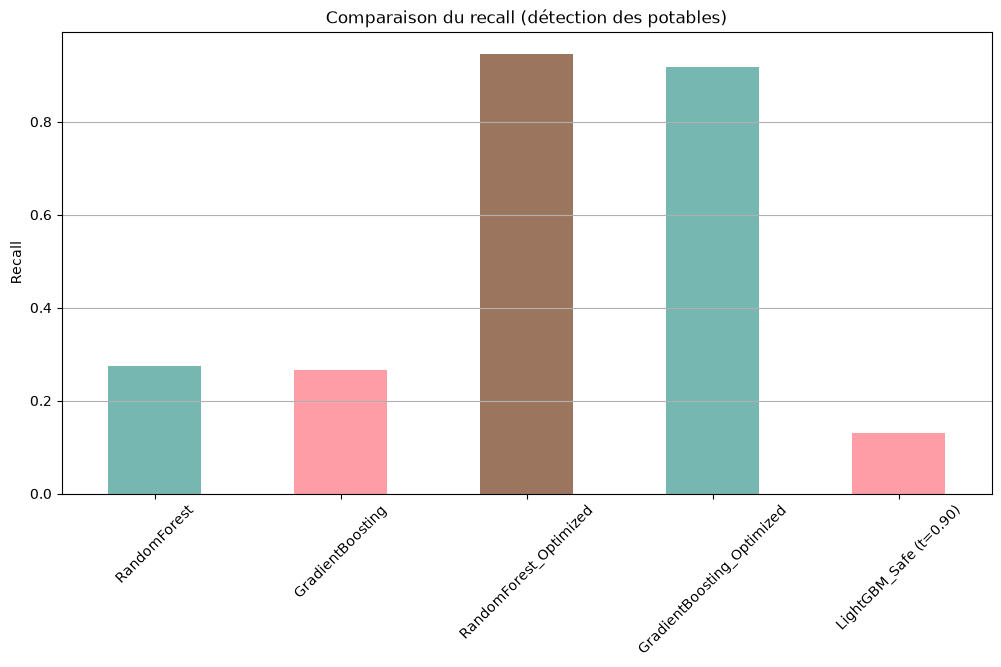

In [42]:
plt.figure(figsize=(12,6))
plt.title("Comparaison du recall (détection des potables)")

df_all["recall"].plot(kind="bar", color=["#76b7b2", "#ff9da7", "#9c755f"])
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


In [43]:
print("=== Conclusion automatique ===\n")

print("Objectif métier : ne jamais dire qu'une eau est potable si elle ne l'est pas.\n")

print("→ Le critère principal est la PRÉCISION (minimisation des faux positifs).")
print("→ Le modèle LightGBM_Safe est le meilleur pour cet objectif.\n")

print("Modèle sélectionné :", "LightGBM_Safe")
print(f"Seuil de sécurité retenu : {best_safe_threshold:.2f}")


=== Conclusion automatique ===

Objectif métier : ne jamais dire qu'une eau est potable si elle ne l'est pas.

→ Le critère principal est la PRÉCISION (minimisation des faux positifs).
→ Le modèle LightGBM_Safe est le meilleur pour cet objectif.

Modèle sélectionné : LightGBM_Safe
Seuil de sécurité retenu : 0.90


In [45]:
import joblib

joblib.dump(lgb_safe, "../models/model_lightgbm_safe.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(best_safe_threshold, "../models/threshold_safe.pkl")

print("Modèle LightGBM sécurisé exporté dans /models/")


Modèle LightGBM sécurisé exporté dans /models/


In [46]:
importances.to_csv("../models/feature_importances_lightgbm.csv")
print("Importances des features exportées.")


Importances des features exportées.


In [47]:
example_bias, example_explanation = explain_prediction(lgb_safe, X_test.iloc[[0]], X.columns)
example_explanation.to_csv("../models/example_explanation.csv")
print("Explication locale exportée.")


Explication locale exportée.
